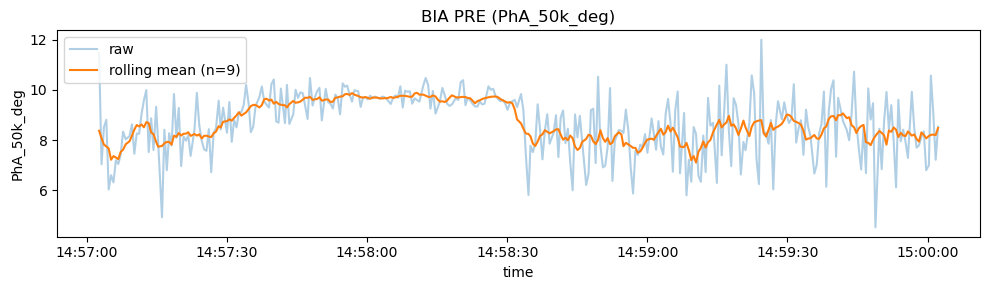

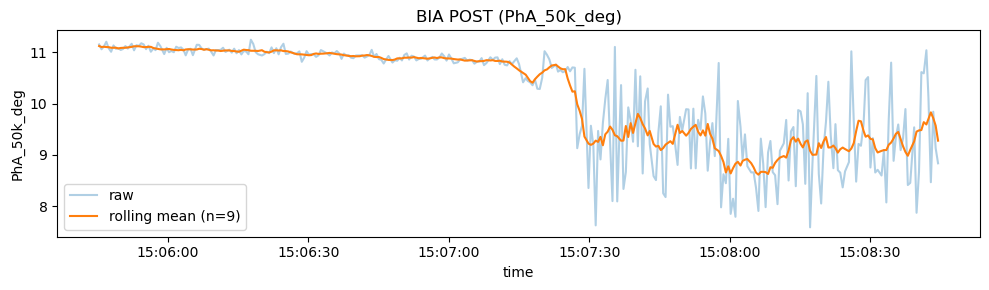


VARIABLES À UTILISER
- bia_pre   : DataFrame PRE (colonnes: time, PhA_50k_deg, etc.)
- bia_post  : DataFrame POST (colonnes: time, PhA_50k_deg, etc.)
- pha_pre   : numpy array, PhA_50k_deg sur PRE
- pha_post  : numpy array, PhA_50k_deg sur POST
- t_pre     : numpy array, temps (s) relatif au début de PRE
- t_post    : numpy array, temps (s) relatif au début de POST
- fs_pre_est  : float, fs approx PRE (= 1 / dt_médian)
- fs_post_est : float, fs approx POST (= 1 / dt_médian)


In [1]:

# BIA RAW IMPORT -> PhA_50k -> PRE/POST WINDOWS -> OUTPUT VARS
# RAW, NO FILTERING / NO RESAMPLING IMPOSED

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# CONFIG 

BIA_PKL_PATH = "../data/LEA_BIA_RAW.pkl"   # pkl file exported from BIA device (raw data for pandas)
FREQ_COL = "f_48800"              # ~50 kHz complex impedance column

# Window timestamps (BIA datetime): 3 minutes BEFORE / fatigue inducing protocole / and 3 minutes AFTER
PRE_START_TIME  = "2025-11-28 14:57:02.563"
PRE_END_TIME    = "2025-11-28 15:00:02.563"
POST_START_TIME = "2025-11-28 15:05:45.278"
POST_END_TIME   = "2025-11-28 15:08:44.534"


# LOAD RAW BIA (.pkl)
data_bia_raw = pd.read_pickle(BIA_PKL_PATH)


# ANALYSIS DATAFRAME (same data, cleaner columns)
data_bia = data_bia_raw.copy()

# Parse time
data_bia["time"] = pd.to_datetime(data_bia["timestamp"], errors="coerce")
data_bia = data_bia.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

# Complex impedance at ~50 kHz
data_bia["Z_50k"] = data_bia[FREQ_COL].astype(np.complex128)

# Compute R, Xc, PhA (standard convention: Xc = -imag(Z))
data_bia["R_50k_ohm"]   = np.real(data_bia["Z_50k"])
data_bia["Xc_50k_ohm"]  = -np.imag(data_bia["Z_50k"])
data_bia["PhA_50k_deg"] = np.degrees(np.arctan2(data_bia["Xc_50k_ohm"], data_bia["R_50k_ohm"]))

# Compact analysis view
analysis_cols = ["time", "Z_50k", "R_50k_ohm", "Xc_50k_ohm", "PhA_50k_deg", "sat", "min", "max"]
data_bia_analysis = data_bia[analysis_cols].copy()

# CREATE WINDOWS (PRE / POST)

pre_start  = pd.to_datetime(PRE_START_TIME)
pre_end    = pd.to_datetime(PRE_END_TIME)
post_start = pd.to_datetime(POST_START_TIME)
post_end   = pd.to_datetime(POST_END_TIME)

def slice_window(df, t0, t1):
    m = (df["time"] >= t0) & (df["time"] <= t1)  # inclusive bounds [start, end]
    return df.loc[m].copy()

bia_pre  = slice_window(data_bia_analysis, pre_start, pre_end)
bia_post = slice_window(data_bia_analysis, post_start, post_end)


#  PLOTS (just for verification)

def plot_window(df_win, title, y_col="PhA_50k_deg", smooth_n=9):
    if len(df_win) < 5:
        print("Not enough points to plot:", title)
        return
    d = df_win.copy()
    d["time"] = pd.to_datetime(d["time"])
    d = d.sort_values("time")
    y = pd.to_numeric(d[y_col], errors="coerce")
    y_sm = y.rolling(smooth_n, center=True, min_periods=1).mean()

    plt.figure(figsize=(10,3))
    plt.plot(d["time"], y, alpha=0.35, label="raw")
    plt.plot(d["time"], y_sm, label=f"rolling mean (n={smooth_n})")
    plt.title(title)
    plt.xlabel("time")
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_window(bia_pre,  "BIA PRE (PhA_50k_deg)")
plot_window(bia_post, "BIA POST (PhA_50k_deg)")


# OUTPUT (variables to use)

pha_pre  = bia_pre["PhA_50k_deg"].astype(float).dropna().to_numpy()
pha_post = bia_post["PhA_50k_deg"].astype(float).dropna().to_numpy()

t_pre  = (bia_pre["time"]  - bia_pre["time"].iloc[0]).dt.total_seconds().to_numpy()
t_post = (bia_post["time"] - bia_post["time"].iloc[0]).dt.total_seconds().to_numpy()

dt_pre_med  = float(bia_pre["time"].diff().dt.total_seconds().median())
dt_post_med = float(bia_post["time"].diff().dt.total_seconds().median())
fs_pre_est  = 1.0 / dt_pre_med
fs_post_est = 1.0 / dt_post_med

print("\nVARIABLES À UTILISER")
print("- bia_pre   : DataFrame PRE (colonnes: time, PhA_50k_deg, etc.)")
print("- bia_post  : DataFrame POST (colonnes: time, PhA_50k_deg, etc.)")
print("- pha_pre   : numpy array, PhA_50k_deg sur PRE")
print("- pha_post  : numpy array, PhA_50k_deg sur POST")
print("- t_pre     : numpy array, temps (s) relatif au début de PRE")
print("- t_post    : numpy array, temps (s) relatif au début de POST")
print("- fs_pre_est  : float, fs approx PRE (= 1 / dt_médian)")
print("- fs_post_est : float, fs approx POST (= 1 / dt_médian)")


TAU ESTIMATES (from ACF)
PRE : tau_1e=1 | tau_first_min=3 | chosen_tau=3 lags (~1.539s)
POST: tau_1e=63| tau_first_min=2| chosen_tau=2 lags (~1.026s)


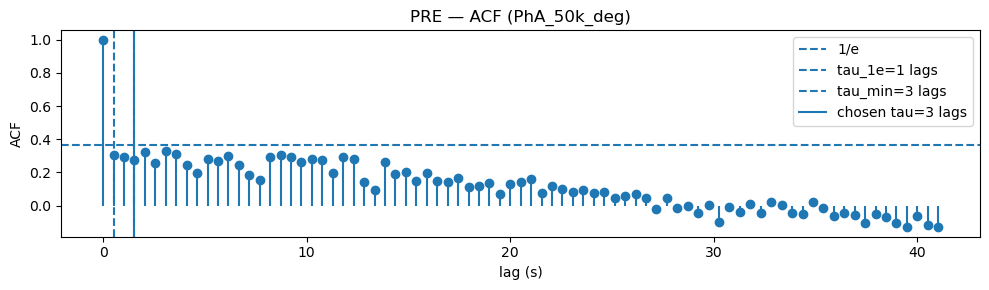

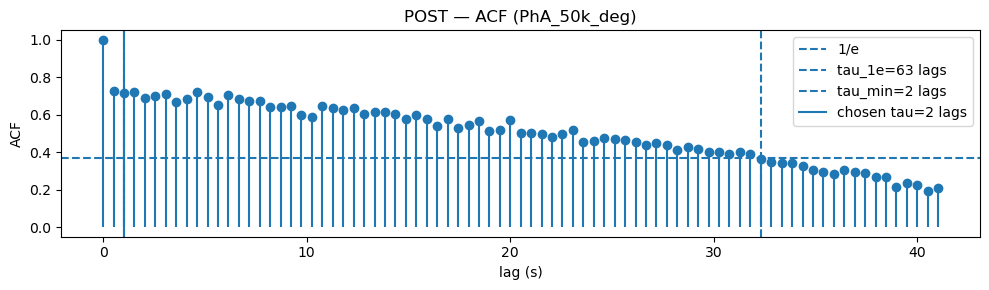

In [2]:
# ACF + tau (1/e crossing + first local minimum)

from statsmodels.tsa.stattools import acf


# 0) Extract signals (shared reference)

pha_pre  = bia_pre["PhA_50k_deg"].astype(float).dropna().to_numpy()
pha_post = bia_post["PhA_50k_deg"].astype(float).dropna().to_numpy()



# 1) Tau estimators from ACF

def estimate_tau_from_acf(x, max_lag=80):
    """
    Returns:
      tau_1e  : first lag where ACF < 1/e (None if never)
      tau_min : first local minimum of ACF (None if none found)
      acf_vals: array ACF[0..max_lag]
    """
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    # safety
    if len(x) < max_lag + 5:
        max_lag = max(10, len(x)//5)

    acf_vals = acf(x, nlags=max_lag, fft=True)
    target = 1 / np.e

    tau_1e = None
    for k in range(1, len(acf_vals)):
        if acf_vals[k] < target:
            tau_1e = k
            break

    tau_min = None
    for k in range(2, len(acf_vals) - 1):
        if acf_vals[k] < acf_vals[k-1] and acf_vals[k] < acf_vals[k+1]:
            tau_min = k
            break

    return tau_1e, tau_min, acf_vals


# 2) Compute ACF + taus

MAX_LAG = 80

tau1e_pre,  tauMin_pre,  acf_pre  = estimate_tau_from_acf(pha_pre,  max_lag=MAX_LAG)
tau1e_post, tauMin_post, acf_post = estimate_tau_from_acf(pha_post, max_lag=MAX_LAG)

# Choose a default tau (prefer local minimum; fallback to 1/e)
tau_pre_lag  = tauMin_pre  if tauMin_pre  is not None else tau1e_pre
tau_post_lag = tauMin_post if tauMin_post is not None else tau1e_post

tau_pre_sec  = None if tau_pre_lag  is None else tau_pre_lag  * dt_pre_med
tau_post_sec = None if tau_post_lag is None else tau_post_lag * dt_post_med

print("TAU ESTIMATES (from ACF)")
print(f"PRE : tau_1e={tau1e_pre} | tau_first_min={tauMin_pre} | chosen_tau={tau_pre_lag} lags (~{tau_pre_sec:.3f}s)")
print(f"POST: tau_1e={tau1e_post}| tau_first_min={tauMin_post}| chosen_tau={tau_post_lag} lags (~{tau_post_sec:.3f}s)")


# 3) Plot ACF (PRE + POST) with tau markers

def plot_acf_with_tau(acf_vals, title, dt_med, tau1e, tauMin, chosen_tau):
    lags = np.arange(len(acf_vals))
    t_lags = lags * dt_med
    target = 1 / np.e

    plt.figure(figsize=(10, 3))
    plt.stem(t_lags, acf_vals, basefmt=" ")
    plt.axhline(target, linestyle="--", label="1/e")

    if tau1e is not None:
        plt.axvline(tau1e * dt_med, linestyle="--", label=f"tau_1e={tau1e} lags")
    if tauMin is not None:
        plt.axvline(tauMin * dt_med, linestyle="--", label=f"tau_min={tauMin} lags")
    if chosen_tau is not None:
        plt.axvline(chosen_tau * dt_med, linestyle="-", label=f"chosen tau={chosen_tau} lags")

    plt.title(title)
    plt.xlabel("lag (s)")
    plt.ylabel("ACF")
    plt.tight_layout()
    plt.legend()
    plt.show()

plot_acf_with_tau(acf_pre,  "PRE — ACF (PhA_50k_deg)",  dt_pre_med,  tau1e_pre,  tauMin_pre,  tau_pre_lag)
plot_acf_with_tau(acf_post, "POST — ACF (PhA_50k_deg)", dt_post_med, tau1e_post, tauMin_post, tau_post_lag)


## Nonlinear Analysis

### Perform phase space reconstruction

The first step to perform phase space reconstruction is to determine optimal time delay. Based on the previous ACF computations, the optimal time delay is 3 for PRE and 2 for POST. 

But other methods to estimate the optimal time delay exists, such a using the first minimum of the mutual information. 



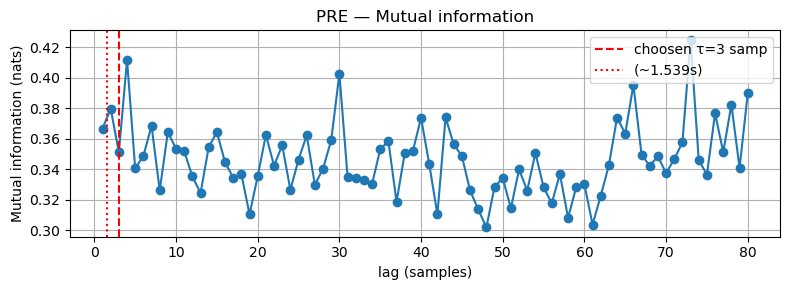

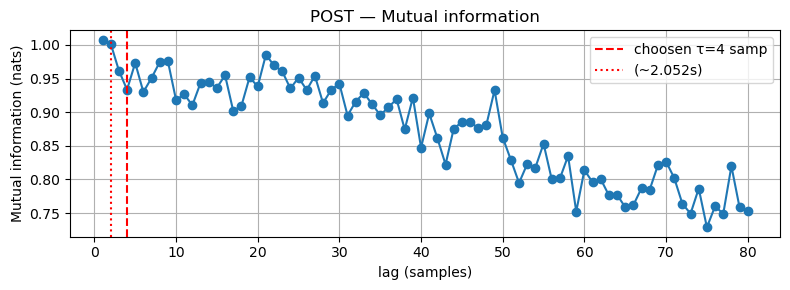

MI-based taus -> PRE: 3 samp (~1.5390000000000001)  |  POST: 4 samp (~2.052)


In [ ]:

# Mutual Information-based tau estimation

def _mutual_information(x, y, bins=32):
    H, _, _ = np.histogram2d(x, y, bins=bins)
    s = H.sum()
    if s == 0:
        return 0.0
    pxy = H / s
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    ix, jy = np.nonzero(pxy)
    mi = np.sum(pxy[ix, jy] * np.log(pxy[ix, jy] / (px[ix] * py[jy])))
    return float(mi)

def compute_mi_lags(x, max_lag=80, bins=32):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return np.array([]), np.array([])
    max_lag = min(max_lag, max(1, len(x)//2 - 1))
    lags = np.arange(1, max_lag+1)
    mis = [ _mutual_information(x[:-lag], x[lag:], bins=bins) for lag in lags ]
    return lags, np.array(mis)

def first_local_minimum(lags, vals):
    for i in range(1, len(vals)-1):
        if vals[i] < vals[i-1] and vals[i] < vals[i+1]:
            return int(lags[i])
    return None

def plot_mi(lags, mis, chosen_tau=None, dt=None, title="Mutual information vs lag"):
    plt.figure(figsize=(8,3))
    plt.plot(lags, mis, '-o')
    if chosen_tau is not None:
        plt.axvline(chosen_tau, color='red', linestyle='--', label=f'choosen τ={chosen_tau} samp')
        if dt is not None:
            plt.axvline(chosen_tau*dt, color='red', linestyle=':', label=f'(~{chosen_tau*dt:.3f}s)')
    plt.xlabel('lag (samples)')
    plt.ylabel('Mutual information (nats)')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- compute MI-based taus for PRE / POST
MAX_LAG = 80
bins_pre  = max(16, int(np.sqrt(len(pha_pre))))  if len(pha_pre)  > 0 else 32
bins_post = max(16, int(np.sqrt(len(pha_post)))) if len(pha_post) > 0 else 32

lags_pre, mi_pre = compute_mi_lags(pha_pre,  max_lag=MAX_LAG, bins=bins_pre)
tau_pre_mi = first_local_minimum(lags_pre, mi_pre) if lags_pre.size else None
plot_mi(lags_pre, mi_pre, chosen_tau=tau_pre_mi, dt=dt_pre_med, title='PRE — Mutual information')

lags_post, mi_post = compute_mi_lags(pha_post, max_lag=MAX_LAG, bins=bins_post)
tau_post_mi = first_local_minimum(lags_post, mi_post) if lags_post.size else None
plot_mi(lags_post, mi_post, chosen_tau=tau_post_mi, dt=dt_post_med, title='POST — Mutual information')

# integrate with existing estimates
tau_pre_lag  = int(tau_pre_mi)  if tau_pre_mi  is not None else (tau_pre_lag  if 'tau_pre_lag' in globals()  else None)
tau_post_lag = int(tau_post_mi) if tau_post_mi is not None else (tau_post_lag if 'tau_post_lag' in globals() else None)

tau_pre_sec  = None if tau_pre_lag  is None else tau_pre_lag  * dt_pre_med
tau_post_sec = None if tau_post_lag is None else tau_post_lag * dt_post_med

print(f"MI-based taus -> PRE: {tau_pre_mi} samp (~{tau_pre_sec})  |  POST: {tau_post_mi} samp (~{tau_post_sec})")

The results do not show big differences regarding the estimated tau between ACF first minimum (PRE = 3; POST = 2) and Average Mutual Information first minimum (PRE = 3; POST = 4).


Now, let's estimate the optimal d 

In [ ]:
def false_nearest_neighbors(signal, max_dim=10, tau=1, r_thresh=15.0, atol=2.0):
    """
    Estimate embedding dimension using the False Nearest Neighbors (FNN) method.

    Parameters
    ----------
    signal : array-like
        Time series (standardized).
    max_dim : int
        Maximum embedding dimension to test.
    tau : int
        Time delay between points (1 = consecutive points).
    r_thresh : float
        Distance ratio threshold to decide if a neighbor is false.
    atol : float
        Absolute distance threshold.

    Returns
    -------
    fnn_percentages : list of float
        Percentage of false nearest neighbors for each dimension.
    """
    signal = np.asarray(signal)
    N = len(signal)
    fnn_percentages = []

    for m in range(1, max_dim + 1):
        # Ensure we have enough data points for dimension m+1
        if N - (m + 1) * tau <= 1:
            break

        # Build state-space embeddings for dimensions m and m+1
        Xm = np.array([signal[i:i + m * tau:tau] for i in range(N - m * tau)])
        Xm1 = np.array([signal[i:i + (m + 1) * tau:tau] for i in range(N - (m + 1) * tau)])

        # Adjust nearest neighbor indices to match shorter Xm1
        min_len = min(len(Xm), len(Xm1))
        Xm = Xm[:min_len]
        Xm1 = Xm1[:min_len]

        # Compute distances in dimension m
        dist_m = np.linalg.norm(Xm[:, None] - Xm[None, :], axis=2)
        np.fill_diagonal(dist_m, np.inf)

        nn_index = np.argmin(dist_m, axis=1)
        nn_dist = np.min(dist_m, axis=1)

        # Compute distances in dimension m+1 safely
        dist_m1 = np.linalg.norm(Xm1 - Xm1[nn_index], axis=1)

        # Ratio of distance growth
        R = np.abs(dist_m1 - nn_dist) / nn_dist
        false_neighbors = np.where((R > r_thresh) | (np.abs(dist_m1) > atol))[0]
        fnn_percent = 100 * len(false_neighbors) / len(Xm1)
        fnn_percentages.append(fnn_percent)

    return fnn_percentages


In [40]:
fnn_values = false_nearest_neighbors(pha_pre, max_dim=10, tau=3)

# Afficher les résultats
for dim, fnn in enumerate(fnn_values, start=1):
    print(f"Dimension {dim}: {fnn:.2f}% False Nearest Neighbors")
    

fnn_values = false_nearest_neighbors(pha_post, max_dim=10, tau=4)

# Afficher les résultats
for dim, fnn in enumerate(fnn_values, start=1):
    print(f"Dimension {dim}: {fnn:.2f}% False Nearest Neighbors")

fnn_values = false_nearest_neighbors(pha_post, max_dim=10, tau=2)

# Afficher les résultats
for dim, fnn in enumerate(fnn_values, start=1):
    print(f"Dimension {dim}: {fnn:.2f}% False Nearest Neighbors")


Dimension 1: 88.18% False Nearest Neighbors
Dimension 2: 30.28% False Nearest Neighbors
Dimension 3: 11.73% False Nearest Neighbors
Dimension 4: 17.76% False Nearest Neighbors
Dimension 5: 27.36% False Nearest Neighbors
Dimension 6: 33.65% False Nearest Neighbors
Dimension 7: 42.31% False Nearest Neighbors
Dimension 8: 50.49% False Nearest Neighbors
Dimension 9: 60.78% False Nearest Neighbors
Dimension 10: 65.02% False Nearest Neighbors
Dimension 1: 86.28% False Nearest Neighbors
Dimension 2: 20.68% False Nearest Neighbors
Dimension 3: 5.94% False Nearest Neighbors
Dimension 4: 4.75% False Nearest Neighbors
Dimension 5: 5.45% False Nearest Neighbors
Dimension 6: 7.47% False Nearest Neighbors
Dimension 7: 10.53% False Nearest Neighbors
Dimension 8: 14.00% False Nearest Neighbors
Dimension 9: 17.57% False Nearest Neighbors
Dimension 10: 23.63% False Nearest Neighbors
Dimension 1: 88.25% False Nearest Neighbors
Dimension 2: 23.64% False Nearest Neighbors
Dimension 3: 5.49% False Nearest N

La ou le pourcentage est le plus bas :
- pour PRE c'est dimension 3
- pour POST c'est 4 pour tau =4 et 3 pour tau=2


Based on those estimated time delay and embedding dimensions, I will plot 2D and 3D phase space reconstruction. Because the estimated time delay in the POST condition can be 2 or 4, I will compute both and visually compare them. 

In [28]:
from mpl_toolkits.mplot3d import Axes3D

def embed_time_series(x, d, tau):
    """
    Create embedded vectors from a 1D time series.
    Each vector = [x(t), x(t+tau), ..., x(t+(d-1)*tau)].
    """
    x = np.asarray(x, dtype=float)
    n = len(x) - (d - 1) * tau
    if n <= 0:
        raise ValueError("Time series too short for given d and tau")
    return np.array([x[i:i + d * tau:tau] for i in range(n)])


def plot_phase_space(x, tau, d, name="Signal"):
    """
    Plot 2D (x(t), x(t+τ)) and 3D (x(t), x(t+τ), x(t+2τ)) projections 
    from a phase space reconstructed with dimension d and delay tau.
    """
    if x is None or len(x) < 10:
        print(f"Signal {name} too short to plot.")
        return

    # --- 2D projection (first two components) ---
    emb = embed_time_series(x, d=d, tau=tau)
    plt.figure(figsize=(6, 6))
    plt.plot(emb[:, 0], emb[:, 1], color='royalblue', lw=0.8, alpha=0.8)
    plt.xlabel('x(t)')
    plt.ylabel(f'x(t+{tau})')
    plt.title(f'{name} – 2D Projection (d={d}, τ={tau})')
    plt.tight_layout()
    plt.show()

    # --- 3D projection (first three components) ---
    if d >= 3:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(emb[:, 0], emb[:, 1], emb[:, 2], color='royalblue', lw=0.8, alpha=0.8)
        ax.set_xlabel('x(t)')
        ax.set_ylabel(f'x(t+{tau})')
        ax.set_zlabel(f'x(t+2{tau})')
        ax.set_title(f'{name} – 3D Projection (d={d}, τ={tau})')
        plt.tight_layout()
        plt.show()

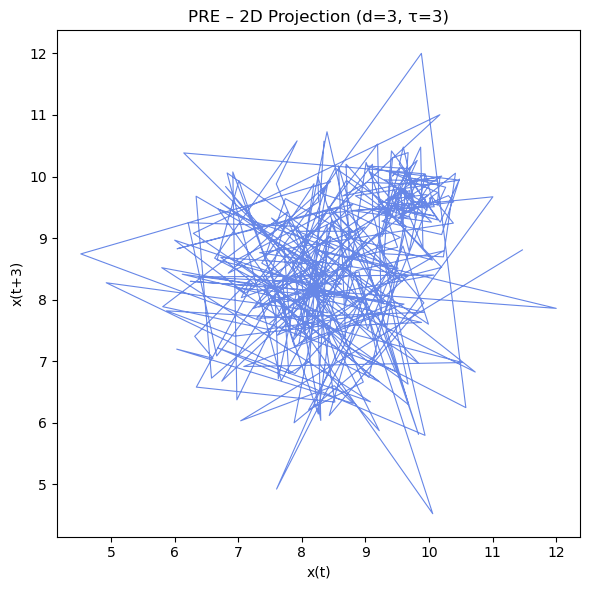

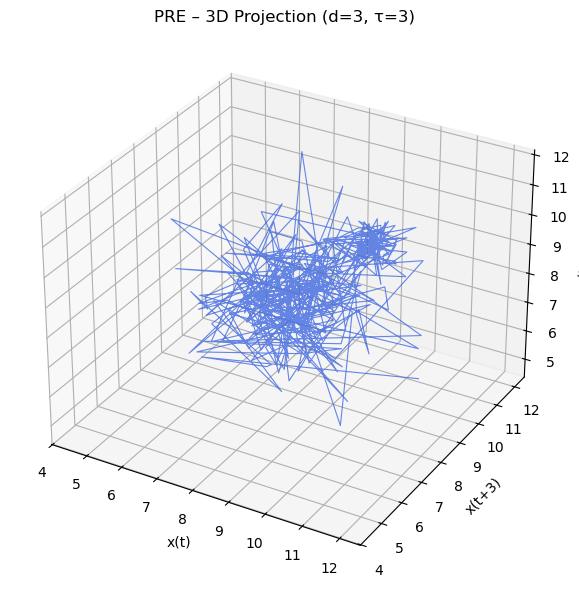

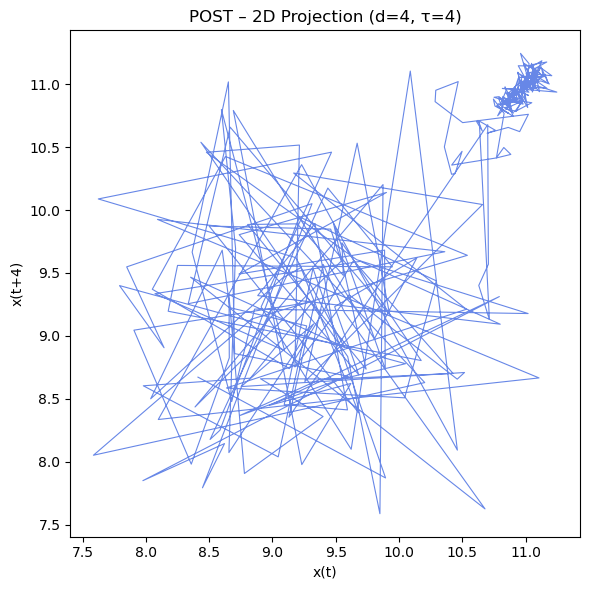

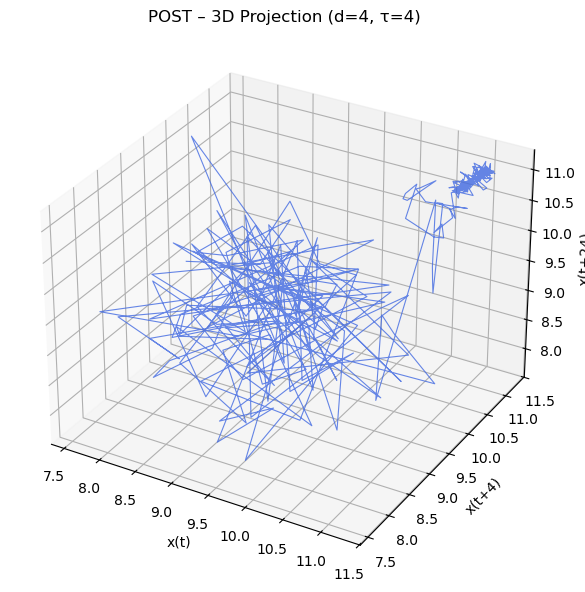

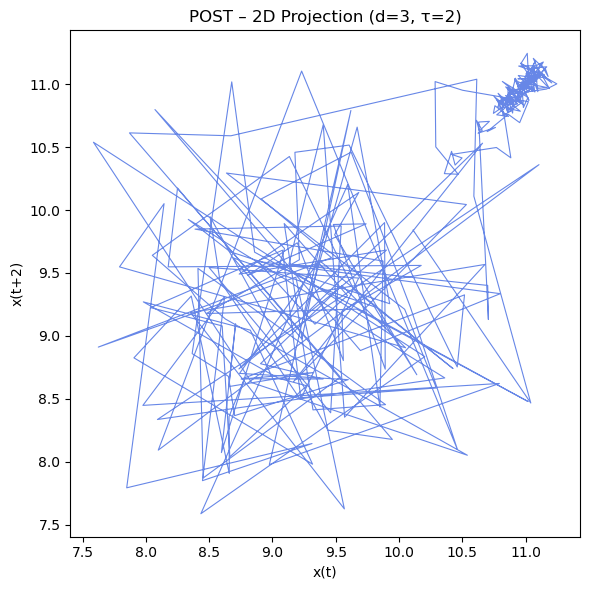

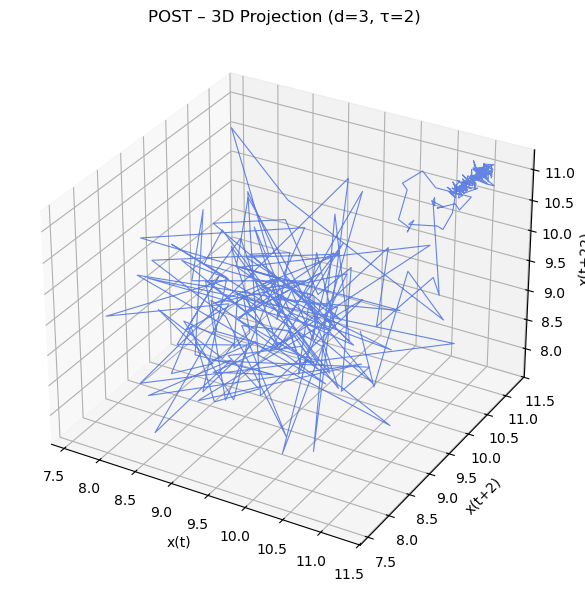

In [41]:
plot_phase_space(pha_pre, tau=3, d=3, name="PRE")
plot_phase_space(pha_post, tau=4, d=4, name="POST")
plot_phase_space(pha_post, tau=2, d=3, name="POST")

It does not seem that there is much discreapency in the phase space reconstruction weither tau is 2 or 4 for the POST CONDITION. 

Interpretation ? Le PRE parait un peu plus complexe que le POST où on pourrait voir une forme ?

## Sample Entropy

SampEn is used to measure the complexity and regularity of time series data. SampEn is a unique number (e.g., 0.15 or 1.17).
SampEn counts how many patterns (sequences) repeat within a time series.

**Formula:**
SampEn(m, r, N) = -ln(A / B)

- **B** = number of similar sequences of length *m*  
- **A** = number of similar sequences of length *m+1*  
- **r** = tolerance (maximum acceptable distance)  
- **m** = embedding dimension (length of compared sequences)

**In simple terms:**  
We split the signal into short segments of length *m* and count how many are similar (**B**).  
Then we repeat the process with longer segments (*m+1*) → **A**.  
Finally, we compute:  
**SampEn = -ln(A / B)**


One limitation is that it cannot be directly applied to non stationary data. 
The first step is therefore to segment the data. But does it really make sense to do that when we want to compare the PRE condition with the POST condition? One solution in such cases is detrending.


In [42]:
# Detrending 
from statsmodels.tsa.stattools import adfuller

# Fonction pour détrending polynomial
def detrend_polynomial(signal, order=3):
    x = np.arange(len(signal))
    coeffs = np.polyfit(x, signal, order)
    trend = np.polyval(coeffs, x)
    detrended = signal - trend
    return detrended

# Applique détrending ordre 3
pha_pre_detrended = detrend_polynomial(pha_pre, order=3)
pha_post_detrended = detrend_polynomial(pha_post, order=3)

# Test de stationnarité pour verifier l'effet du detrending
# si p > 0.05 -> non stationnaire
pha_pre_detrended_p = adfuller(pha_pre_detrended)
pha_post_detrended_p = adfuller(pha_post_detrended)
print(f"p-value (ordre 3): {pha_pre_detrended_p[1]}")
print(f"p-value (ordre 3): {pha_post_detrended_p[1]}")

p-value (ordre 3): 0.0002384936422440395
p-value (ordre 3): 0.03299010227362556


--> ca donne un p significatif qua partir de order 3. 
Donc je garde le detrending comme ça.

**(Ca veut dire que les datas sont maintenant bien stationnaire et qu'on peut calculer le SampEn)**

Je vérifie quand même visuellement que les datas ressemblent ben à ce qu'elles devraient avant de continuer

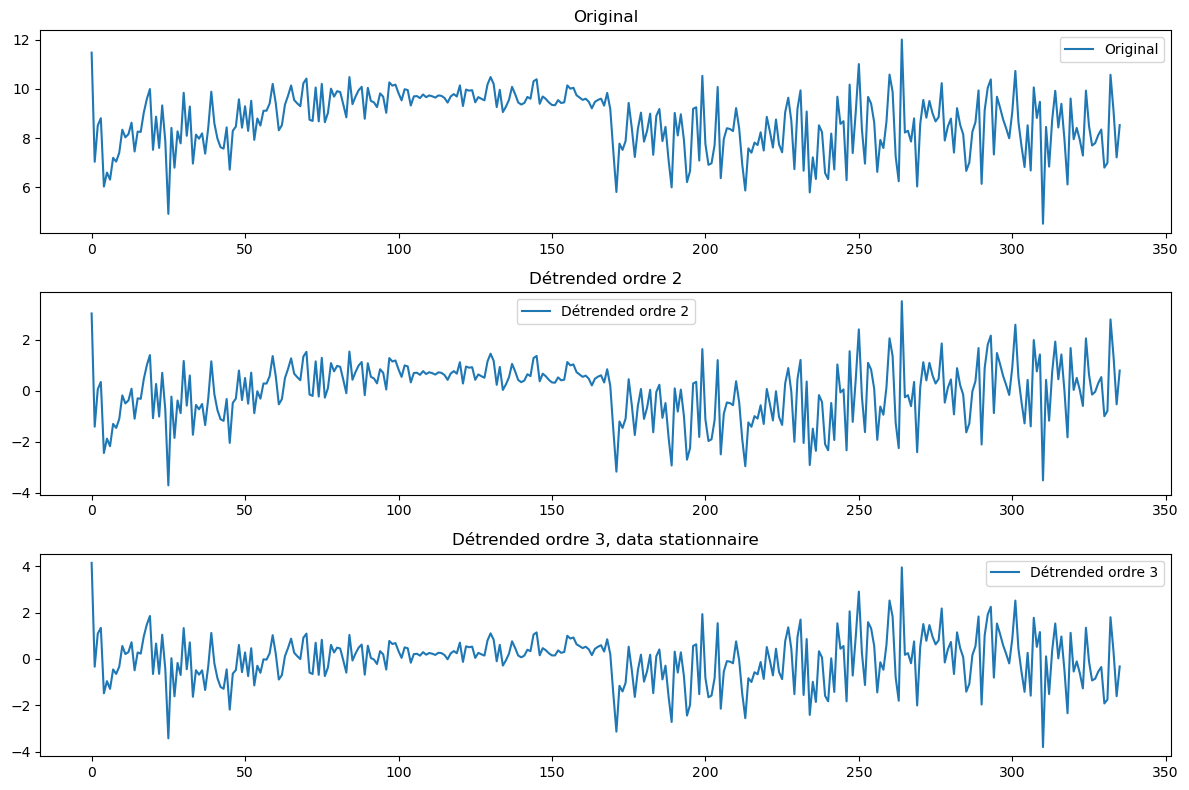

Variance ordre 2: 1.316001524344267
Variance ordre 3: 1.1318288902730003


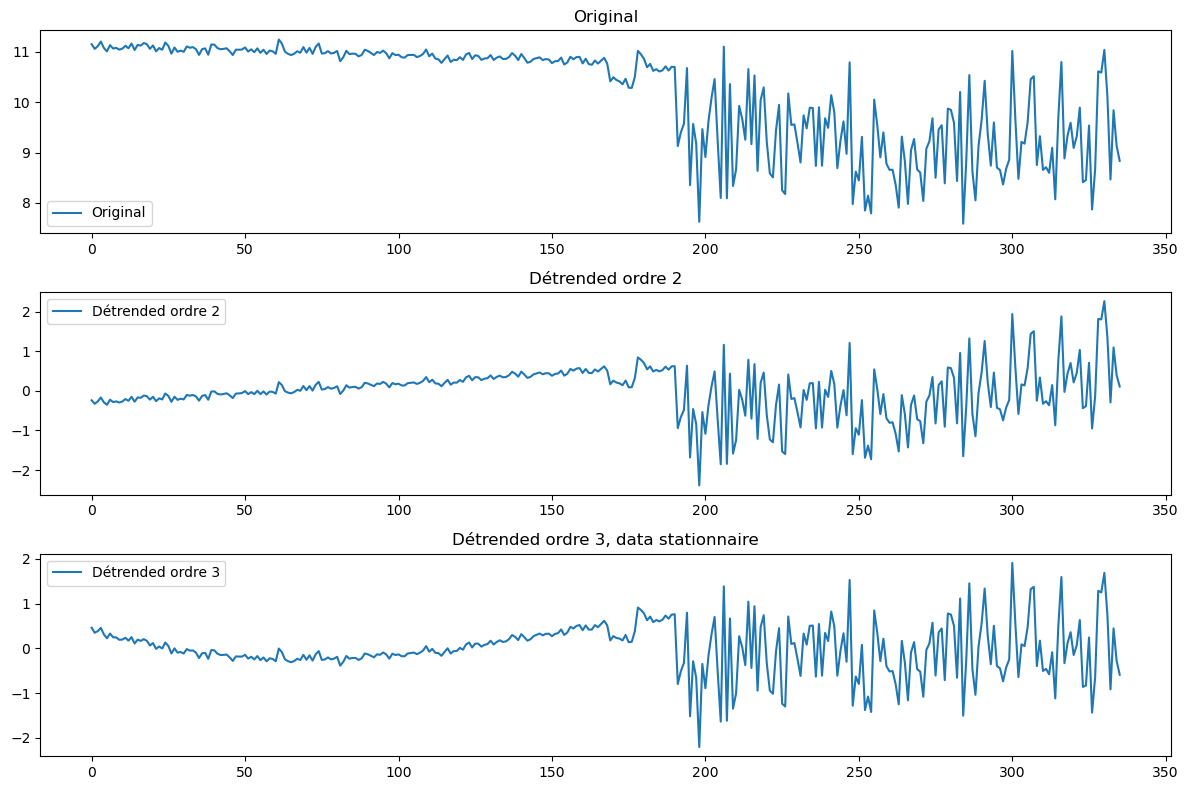

Variance ordre 2: 0.39727241305397676
Variance ordre 3: 0.3249738752951024


In [ ]:
# Comparaison visuelle
# POUR PRE PHA
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(pha_pre, label='Original')
axes[0].set_title('Original')
axes[0].legend()

axes[1].plot(detrend_polynomial(pha_pre, order=2), label='Détrended ordre 2')
axes[1].set_title('Détrended ordre 2')
axes[1].legend()

axes[2].plot(detrend_polynomial(pha_pre, order=3), label='Détrended ordre 3')
axes[2].set_title('Détrended ordre 3, data stationnaire')
axes[2].legend()

plt.tight_layout()
plt.show()

#  variance
print(f"Variance ordre 2: {np.var(detrend_polynomial(pha_pre, order=2))}")
print(f"Variance ordre 3: {np.var(detrend_polynomial(pha_pre, order=3))}")

# POUR POST PHA
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(pha_post, label='Original')
axes[0].set_title('Original')
axes[0].legend()

axes[1].plot(detrend_polynomial(pha_post, order=2), label='Détrended ordre 2')
axes[1].set_title('Détrended ordre 2')
axes[1].legend()

axes[2].plot(detrend_polynomial(pha_post, order=3), label='Détrended ordre 3')
axes[2].set_title('Détrended ordre 3, data stationnaire')
axes[2].legend()

plt.tight_layout()
plt.show()

#  variance
print(f"Variance ordre 2: {np.var(detrend_polynomial(pha_post, order=2))}")
print(f"Variance ordre 3: {np.var(detrend_polynomial(pha_post, order=3))}")


Ca m'a lair ok visuellement !



The second step is to standardize the time series so it's easy to compare signals no matter their scale or units.


In [44]:
pha_pre_std = (pha_pre_detrended - np.mean(pha_pre_detrended)) / np.std(pha_pre_detrended)
pha_post_std = (pha_post_detrended - np.mean(pha_post_detrended)) / np.std(pha_post_detrended)

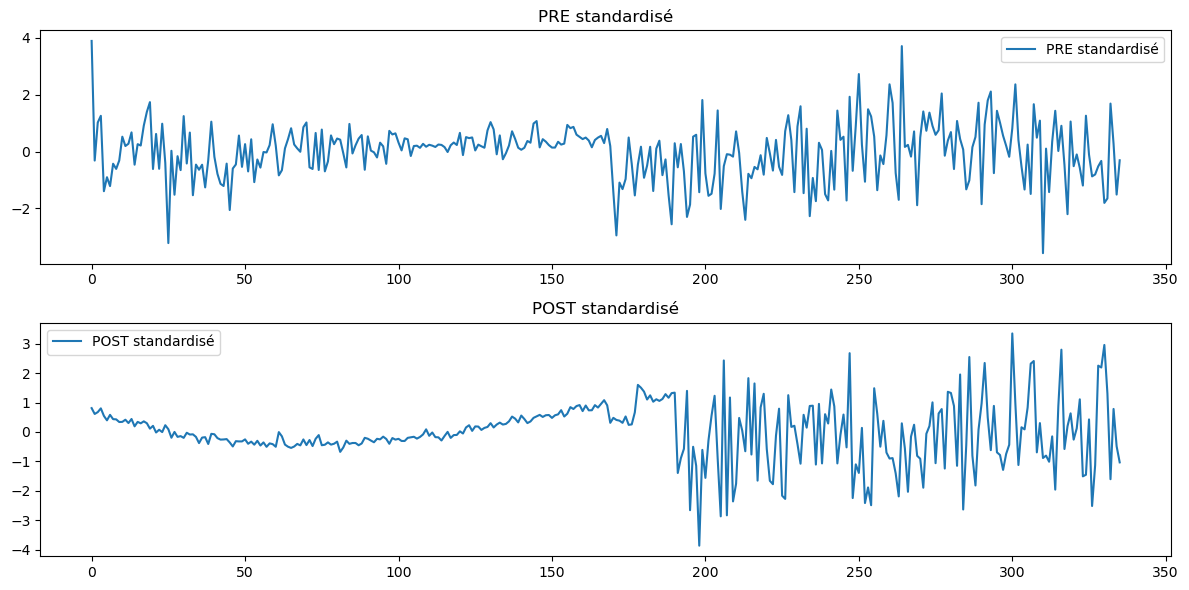

In [45]:
# verification visuelle entre avant / après standardisation pour pre et post
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(pha_pre_std, label='PRE standardisé')
axes[0].set_title('PRE standardisé')
axes[0].legend()
axes[1].plot(pha_post_std, label='POST standardisé')
axes[1].set_title('POST standardisé')
axes[1].legend()
plt.tight_layout()
plt.show()


Now I can compute SampEn

In [52]:
def sample_entropy(signal, m, r):
    """
    Compute Sample Entropy (SampEn) of a time series.

    Parameters
    ----------
    signal : array-like
        Standardized time series (mean = 0, std = 1).
    m : int
        Embedding dimension (length of sequences to compare).
    r : float
        Tolerance (as a fraction of the standard deviation).

    Returns
    -------
    float
        Sample Entropy value (always >= 0).
    """

    N = len(signal)
    signal = np.asarray(signal, dtype=float)

    # Normalize (just to be safe)
    signal = (signal - np.mean(signal)) / np.std(signal)

    # Compute tolerance threshold
    r *= np.std(signal)

    def _embed(signal, m):
        return np.array([signal[i:i+m] for i in range(N - m + 1)])

    Xm = _embed(signal, m)
    Xm1 = _embed(signal, m + 1)

    def _count_matches(X, r):
        count = 0
        for i in range(len(X)):
            dist = np.max(np.abs(X - X[i]), axis=1)
            count += np.sum(dist < r) - 1  # exclude self-match
        return count

    B = _count_matches(Xm, r)
    A = _count_matches(Xm1, r)

    # Handle degenerate cases
    if B <= 0 or A <= 0:
        return np.nan

    # Prevent impossible ratios
    ratio = A / B
    ratio = max(min(ratio, 1.0), 1e-10)  # clamp ratio into [1e-10, 1]

    # Compute Sample Entropy
    SampEn = -np.log(ratio)
    return max(SampEn, 0.0)  # force non-negative


In [62]:
m_values = [3, 4, 5]
r_values = [0.10, 0.20]

print(f"{'m':<3} {'r':<6} {'SampEn PRE':<12} {'SampEn POST':<12}")
print("-" * 50)

for m in m_values:
    for r in r_values:
        val_pre = sample_entropy(pha_pre_std, m=m, r=r)
        val_post = sample_entropy(pha_post_std, m=m, r=r)
        print(f"{m:<3} {r:<6.2f} {val_pre:<12.4f} {val_post:<12.4f}")

m   r      SampEn PRE   SampEn POST 
--------------------------------------------------
3   0.10   0.9614       0.8456      
3   0.20   0.8501       0.3410      
4   0.10   0.4855       0.8492      
4   0.20   0.6360       0.3311      
5   0.10   0.6931       0.7487      
5   0.20   0.5232       0.3490      


J'ai calculé le sample entropy pour différents paramètres. En faisant varier l'embedding dimension (m) et le seuil (r). 

## Compare nonlinear characteristics between conditions

State-space reconstruction via time-delay embedding (τ = 3 for PRE, τ = 4 for POST; d = 3–4) revealed marked topological differences between the two conditions. The PRE attractor displayed complex and spatially extended trajectories characteristic of complexe dynamics, whereas the POST attractor was substantially compressed and confined to a restricted region of phase space, indicating a bifurcation toward simpler dynamics.

Sample Entropy quantified this transition, with a value of 0.8501 for PRE and 0.3410 for POST (for m = 3, r = 0.20 SD), confirming a consistent reduction in complexity following fatigue across all embedding dimensions examined. Results obtained with r = 0.10 showed systematic instability across dimensions m = 3–5, with POST values paradoxically exceeding PRE at m = 4, which validated r = 0.20 as the optimal tolerance threshold. The PRE > POST pattern remained robust and consistent at r = 0.20 across m = 3, 4, and 5, with respective values of 0.6360 versus 0.3311 and 0.5232 versus 0.3490.

Lower SampEn values indicate greater regularity. PRE values suggest dynamics with higher irregularity and complexity, whereas POST values indicate a shift toward more regular and less variable behavior. 

The reduction in complexity observed here parallels findings in cardiac physiology, where decreased heart rate variability entropy correlates with pathological conditions, while healthy dynamics exhibit elevated complexity (REF). Similarly, reduced gait complexity has been shown to predict fall risk and mobility decline in aging populations (REF). The observed reduction in BIA Phase Angle complexity likely reflects fatigue-induced dampening of ion gradients, alterations in membrane polarization, and diminished neuromuscular transmission efficiency, ultimately reducing the fine-scale temporal variability characteristic of healthy contractile states. 


## Surrogate data testing
Goal: generate surrogate data that preserve the linear properties (e.g., power
spectrum) of the original time series but destroy any nonlinear structure.


Used for hypothesis testing: Compare the original time series with surrogates to
detect nonlinearity.

he null hypothesis H0 states that the time series {Xt } is generated by a linear
stochastic ARMA processes with no nonlinear structure


Analysis for: PHA PRE-FATIGUE

Generating 99 iAAFT surrogates...
Generation complete.


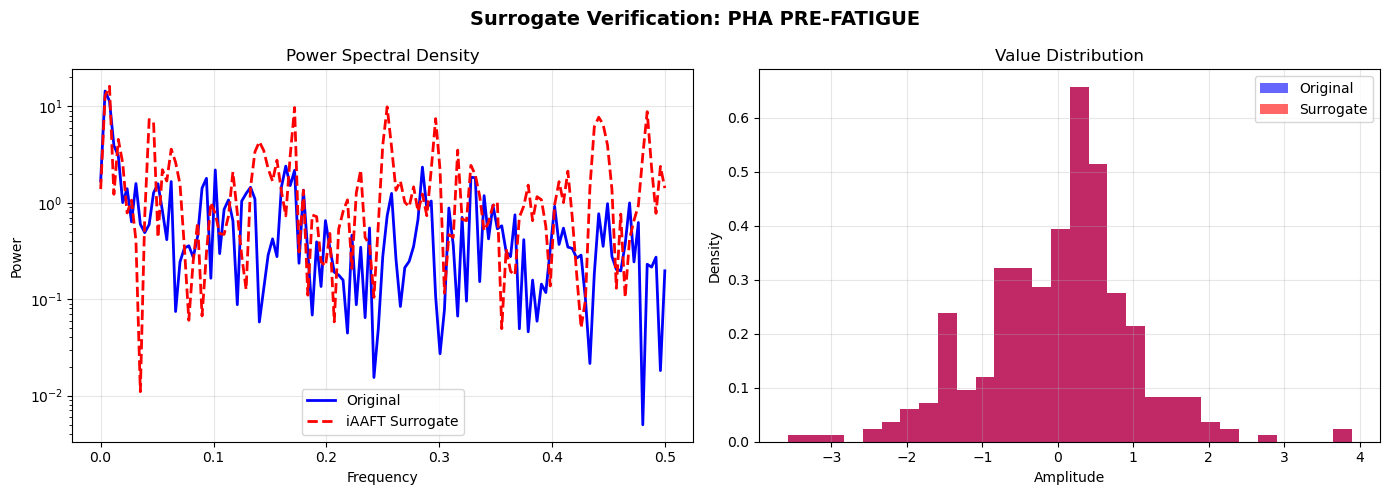


Calculating Sample Entropy (m=3, r=0.2000)...

------------------------------------------------------------
STATISTICAL RESULTS
------------------------------------------------------------
Original SampEn (T0): 0.8501
Surrogate Mean: 2.0609
Surrogate Std Dev: 0.2334
95% Confidence Interval: [1.5942, 2.5277]

------------------------------------------------------------
HYPOTHESIS TEST RESULT
------------------------------------------------------------
T0 = 0.8501 is BELOW the lower bound 1.5942
 H0 is REJECTED
 Signal is MORE REGULAR than surrogates
 NONLINEAR DYNAMICS DETECTED (order-creating)


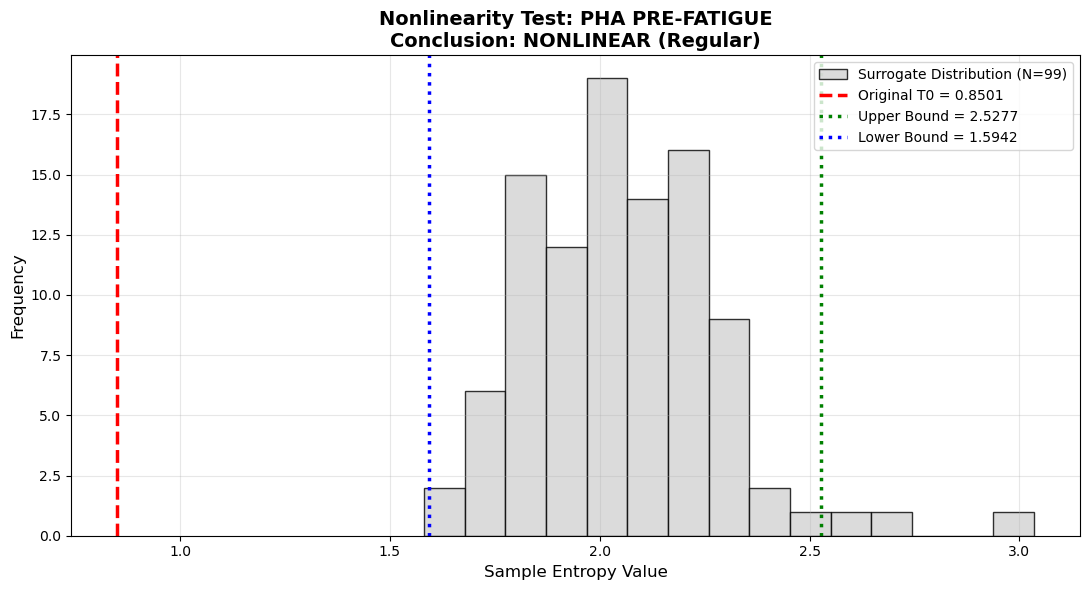


Analysis for: PHA POST-FATIGUE

Generating 99 iAAFT surrogates...
Generation complete.


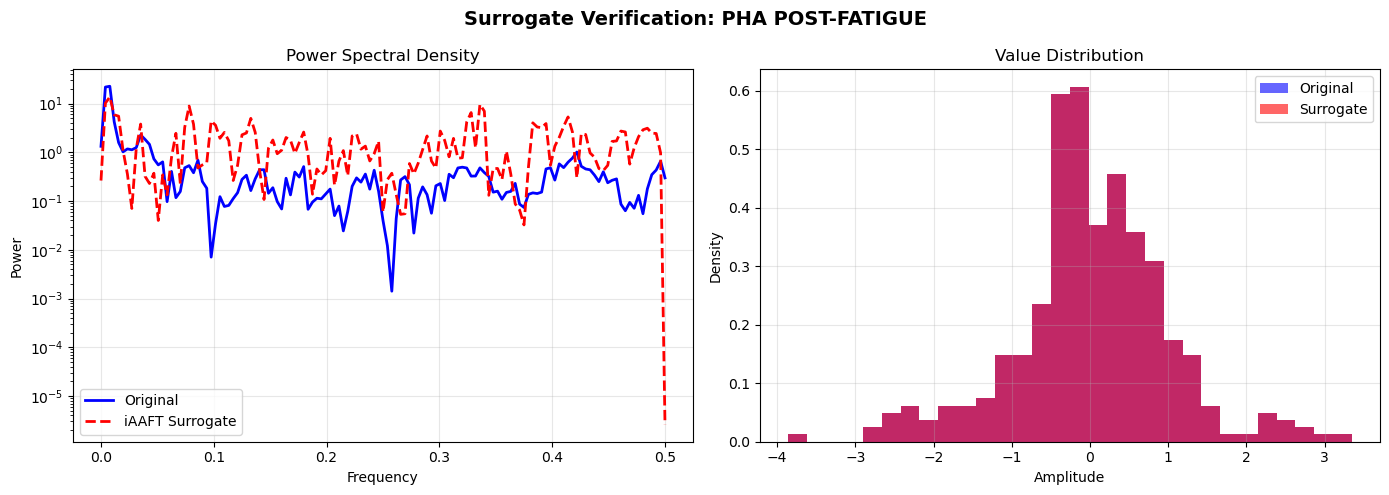


Calculating Sample Entropy (m=3, r=0.2000)...

------------------------------------------------------------
STATISTICAL RESULTS
------------------------------------------------------------
Original SampEn (T0): 0.3410
Surrogate Mean: 1.9968
Surrogate Std Dev: 0.2122
95% Confidence Interval: [1.5724, 2.4211]

------------------------------------------------------------
HYPOTHESIS TEST RESULT
------------------------------------------------------------
T0 = 0.3410 is BELOW the lower bound 1.5724
 H0 is REJECTED
 Signal is MORE REGULAR than surrogates
 NONLINEAR DYNAMICS DETECTED (order-creating)


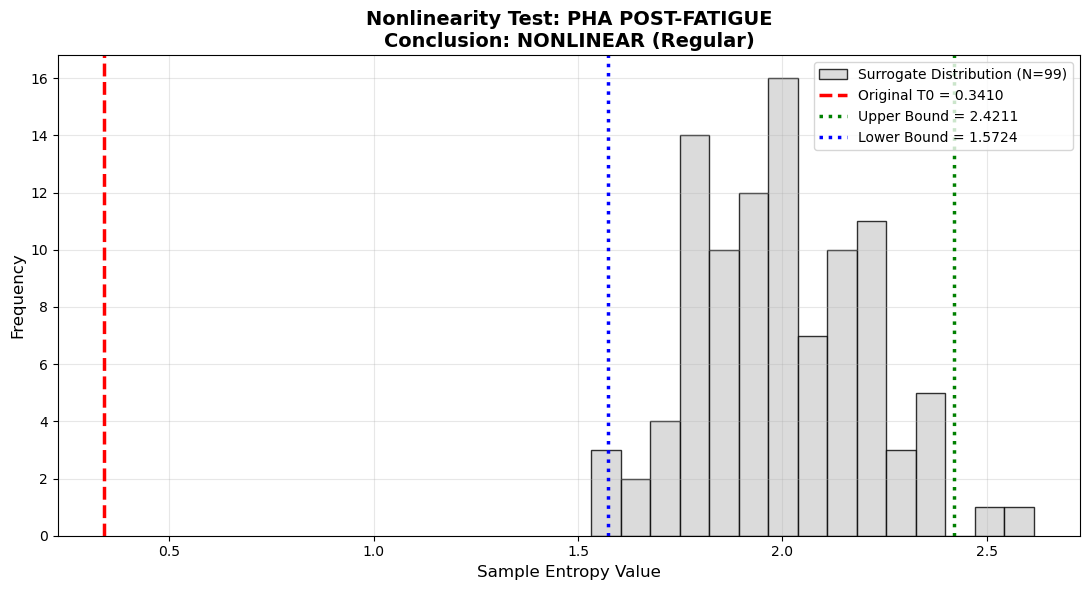


SUMMARY
PRE-FATIGUE: NONLINEAR (Regular)
POST-FATIGUE: NONLINEAR (Regular)


In [67]:
from scipy.fft import fft, ifft
from scipy import signal
from scipy.integrate import odeint

def sample_entropy(signal_input, m, r):
    """Compute Sample Entropy (SampEn) of a time series."""
    N = len(signal_input)
    signal_input = np.asarray(signal_input, dtype=float)
    
    # Normalize
    signal_input = (signal_input - np.mean(signal_input)) / np.std(signal_input)
    
    # Compute tolerance threshold
    r *= np.std(signal_input)
    
    def _embed(sig, dim):
        return np.array([sig[i:i+dim] for i in range(N - dim + 1)])
    
    Xm = _embed(signal_input, m)
    Xm1 = _embed(signal_input, m + 1)
    
    def _count_matches(X, threshold):
        count = 0
        for i in range(len(X)):
            dist = np.max(np.abs(X - X[i]), axis=1)
            count += np.sum(dist < threshold) - 1
        return count
    
    B = _count_matches(Xm, r)
    A = _count_matches(Xm1, r)
    
    if B <= 0 or A <= 0:
        return np.nan
    
    ratio = A / B
    ratio = max(min(ratio, 1.0), 1e-10)
    
    SampEn = -np.log(ratio)
    return max(SampEn, 0.0)

def generate_iAAFT_surrogate(original_series, max_iter=1000, atol=1e-8, rtol=1e-8):
    """Generates an iAAFT surrogate."""
    fourier_transform = fft(original_series)
    target_amplitudes = np.abs(fourier_transform)
    sorted_original = np.sort(original_series)
    current_surrogate = np.random.permutation(original_series)
    
    for _ in range(max_iter):
        # Enforce power spectrum
        surrogate_fft = fft(current_surrogate)
        phases = np.angle(surrogate_fft)
        new_fft = target_amplitudes * np.exp(1j * phases)
        time_domain_series = np.real(ifft(new_fft))
        
        # Enforce value distribution
        ranking = np.argsort(time_domain_series)
        final_surrogate = np.empty_like(current_surrogate)
        final_surrogate[ranking] = sorted_original
        
        # Check convergence
        if np.allclose(current_surrogate, final_surrogate, atol=atol, rtol=rtol):
            break
        
        current_surrogate = final_surrogate
    
    return current_surrogate

def perform_nonlinearity_test(series, series_name, m, r_factor, num_surrogates=99):
    """Performs the complete nonlinearity test on a time series."""
    print(f"\n{'='*60}")
    print(f"Analysis for: {series_name}")
    print(f"{'='*60}")
    
    # Generate surrogates
    print(f"\nGenerating {num_surrogates} iAAFT surrogates...")
    surrogates = [generate_iAAFT_surrogate(series) for _ in range(num_surrogates)]
    print("Generation complete.")
    
    # Verify surrogate properties
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Surrogate Verification: {series_name}', fontsize=14, fontweight='bold')
    
    freqs_orig, psd_orig = signal.welch(series, nperseg=256)
    freqs_surr, psd_surr = signal.welch(surrogates[0], nperseg=256)
    
    axes[0].semilogy(freqs_orig, psd_orig, 'b-', label='Original', linewidth=2)
    axes[0].semilogy(freqs_surr, psd_surr, 'r--', label='iAAFT Surrogate', linewidth=2)
    axes[0].set_title('Power Spectral Density')
    axes[0].set_xlabel('Frequency')
    axes[0].set_ylabel('Power')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(series, bins=30, density=True, color='blue', alpha=0.6, label='Original')
    axes[1].hist(surrogates[0], bins=30, density=True, color='red', alpha=0.6, label='Surrogate')
    axes[1].set_title('Value Distribution')
    axes[1].set_xlabel('Amplitude')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate Sample Entropy
    sd = np.std(series)
    r = r_factor * sd
    print(f"\nCalculating Sample Entropy (m={m}, r={r:.4f})...")
    
    T0 = sample_entropy(series, m, r)
    Ts = [sample_entropy(s, m, r) for s in surrogates]
    
    # Statistical analysis
    mean_surr = np.mean(Ts)
    std_surr = np.std(Ts)
    upper_bound = mean_surr + 2 * std_surr
    lower_bound = mean_surr - 2 * std_surr
    
    print(f"\n{'-'*60}")
    print("STATISTICAL RESULTS")
    print(f"{'-'*60}")
    print(f"Original SampEn (T0): {T0:.4f}")
    print(f"Surrogate Mean: {mean_surr:.4f}")
    print(f"Surrogate Std Dev: {std_surr:.4f}")
    print(f"95% Confidence Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")
    
    # Decision
    print(f"\n{'-'*60}")
    print("HYPOTHESIS TEST RESULT")
    print(f"{'-'*60}")
    
    if T0 < lower_bound:
        print(f"T0 = {T0:.4f} is BELOW the lower bound {lower_bound:.4f}")
        print(" H0 is REJECTED")
        print(" Signal is MORE REGULAR than surrogates")
        print(" NONLINEAR DYNAMICS DETECTED (order-creating)")
        result = "NONLINEAR (Regular)"
    elif T0 > upper_bound:
        print(f"T0 = {T0:.4f} is ABOVE the upper bound {upper_bound:.4f}")
        print(" H0 is REJECTED")
        print(" Signal is MORE COMPLEX than surrogates")
        print(" NONLINEAR DYNAMICS DETECTED (chaotic)")
        result = "NONLINEAR (Chaotic)"
    else:
        print(f"T0 = {T0:.4f} is WITHIN the confidence interval")
        print(" H0 CANNOT BE REJECTED")
        print(" Signal is consistent with linear process")
        result = "LINEAR/STOCHASTIC"
    
    # Visualization
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.hist(Ts, bins=15, color='lightgray', alpha=0.8, edgecolor='black', 
            label=f'Surrogate Distribution (N={num_surrogates})')
    ax.axvline(T0, color='red', linestyle='--', linewidth=2.5, label=f'Original T0 = {T0:.4f}')
    ax.axvline(upper_bound, color='green', linestyle=':', linewidth=2.5, label=f'Upper Bound = {upper_bound:.4f}')
    ax.axvline(lower_bound, color='blue', linestyle=':', linewidth=2.5, label=f'Lower Bound = {lower_bound:.4f}')
    
    ax.set_title(f'Nonlinearity Test: {series_name}\nConclusion: {result}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Sample Entropy Value', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return {
        'T0': T0,
        'mean_surr': mean_surr,
        'std_surr': std_surr,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'result': result
    }

if __name__ == '__main__':
    try:
        pha_pre_std
        pha_post_std
    except NameError:
        print("\n" + "="*60)
        print("Using demo data (variables not found)")
        print("="*60 + "\n")
        
        def lorenz(state, t, sigma=10, rho=28, beta=2.667):
            x, y, z = state
            dx_dt = sigma * (y - x)
            dy_dt = rho * x - y - x * z
            dz_dt = x * y - beta * z
            return [dx_dt, dy_dt, dz_dt]
        
        t = np.arange(0, 10.08, 0.03)
        xyz_init = [0., 1., 1.05]
        lorenz_solution = odeint(lorenz, xyz_init, t)
        pha_pre_std = (lorenz_solution[:, 0] - np.mean(lorenz_solution[:, 0])) / np.std(lorenz_solution[:, 0])
        
        t_post = np.linspace(0, 10, 336)
        post_signal = 0.8 * np.sin(2 * np.pi * 1.5 * t_post) + 0.15 * np.random.randn(len(t_post))
        pha_post_std = (post_signal - np.mean(post_signal)) / np.std(post_signal)
    
    # Run analysis
    m = 3
    r_factor = 0.20
    num_surrogates = 99
    
    results_pre = perform_nonlinearity_test(
        series=pha_pre_std,
        series_name="PHA PRE-FATIGUE",
        m=m,
        r_factor=r_factor,
        num_surrogates=num_surrogates
    )
    
    results_post = perform_nonlinearity_test(
        series=pha_post_std,
        series_name="PHA POST-FATIGUE",
        m=m,
        r_factor=r_factor,
        num_surrogates=num_surrogates
    )
    
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"PRE-FATIGUE: {results_pre['result']}")
    print(f"POST-FATIGUE: {results_post['result']}")
